In [219]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

In [220]:
scores = pd.read_csv('../data/accuracy_by_trial.csv')
scores_by_block = scores.groupby(['sub_num', 'block_num'], as_index = False).accuracy.mean()
scores_by_block = scores_by_block[~scores_by_block.block_num.isin([1, 6, 7])]

**Performance by block**

<Axes: xlabel='block_num', ylabel='accuracy'>

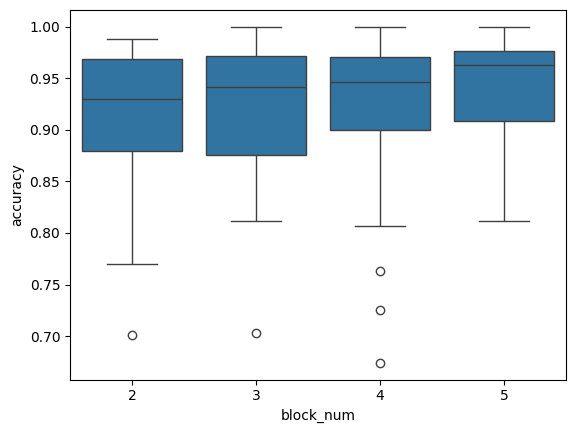

In [221]:
sns.boxplot(scores_by_block, y = 'accuracy', x = 'block_num')

**Performance of each subject**

<Axes: xlabel='block_num', ylabel='accuracy'>

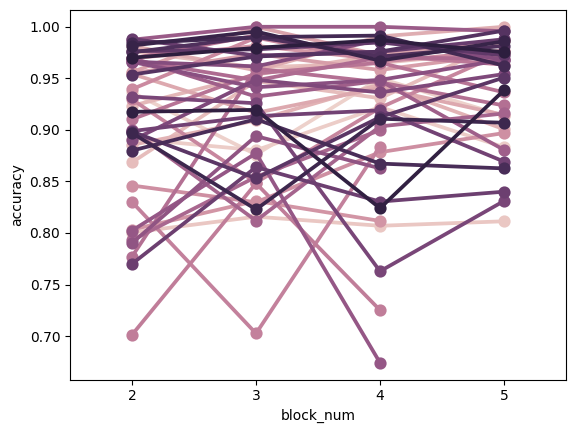

In [222]:
sns.pointplot(data = scores_by_block, x = "block_num", y = "accuracy", hue = 'sub_num', legend = False)

### Add accuracy group

In [223]:
# Add accuracy group to dataframe
scores_by_block = scores_by_block.rename(columns = {'accuracy': 'block_accuracy'})
accuracy = pd.read_csv('accuracy.csv', index_col = 0)
accuracy = accuracy.rename(columns = {'subject': 'sub_num', 'accuracy': 'overall_accuracy'})
scores_by_block = scores_by_block.merge(accuracy, left_on = ["sub_num"], right_on = ["sub_num"])

In [224]:
scores_by_block

,sub_num,block_num,block_accuracy,overall_accuracy,score_group
0,1,2,0.936423,0.896808,low
1,1,3,0.876095,0.896808,low
2,1,4,0.949928,0.896808,low
3,1,5,0.913636,0.896808,low
4,2,2,0.891575,0.896577,low
...,...,...,...,...,...
168,44,5,0.938480,0.902753,low
169,45,2,0.969985,0.979403,high
170,45,3,0.979517,0.979403,high
171,45,4,0.987085,0.979403,high


In [225]:
# Compute difference between first and third block
block2 = scores_by_block[scores_by_block.block_num == 2]
block5 = scores_by_block[scores_by_block.block_num == 5]
block2 = block2.set_index('sub_num')
block5 = block5.set_index('sub_num')
diff = pd.DataFrame(block5.block_accuracy-block2.block_accuracy)
diff = diff.rename(columns = {'block_accuracy': 'diff'})
scores_by_block = scores_by_block.merge(diff, left_on = ["sub_num"], right_on = ["sub_num"])

## Group 1: Consistently high performers

In [226]:
q = np.quantile(scores_by_block.block_accuracy, 0.5)
print(q)
scores_by_block['high_score'] = scores_by_block.block_accuracy > q
subs = []
for sub in np.unique(scores_by_block.sub_num):
    sub_scores = scores_by_block[scores_by_block.sub_num == sub]
    if sum(sub_scores.high_score) == 4:
        subs.append(sub)
print(subs)
consistent_high_performers = scores_by_block[scores_by_block.sub_num.isin(subs)]

0.9441712608379275
[4, 8, 10, 11, 19, 22, 26, 30, 35, 36, 38, 39, 41, 43, 45]


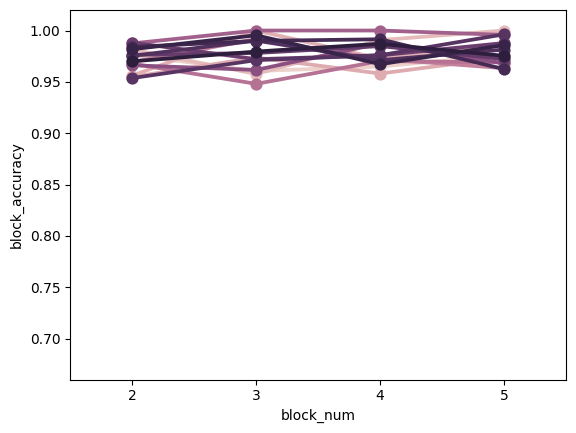

In [227]:
sns.pointplot(data = consistent_high_performers, x = "block_num", y = "block_accuracy", hue = 'sub_num', legend = False)
plt.ylim(0.66, 1.02) 
plt.savefig('../figs/high-performer.png', dpi = 300)

In [228]:
# no_high_performers = scores_by_block[~scores_by_block.sub_num.isin(subs)]
# sns.pointplot(data = no_high_performers, x = "block_num", y = "block_accuracy", hue = 'sub_num')

In [229]:
# # Group visually
# tmp = no_high_performers[no_high_performers.sub_num >= 40]
# tmp['sub_num'] = tmp['sub_num'].astype(str)
# sns.pointplot(data = tmp, x = "block_num", y = "block_accuracy", hue = 'sub_num')

## Group 2: Improvers

In [230]:
# q = np.quantile(no_high_performers.block_accuracy, 0.3)
# print(q)
# no_high_performers['high_score'] = no_high_performers.block_accuracy > q
# subs = []
# for sub in np.unique(no_high_performers.sub_num):
#     sub_scores = no_high_performers[scores_by_block.sub_num == sub]
#     if sum(sub_scores.high_score) == 4:
#         subs.append(sub)
# print(subs)
# improvers = no_high_performers[no_high_performers.sub_num.isin(subs)]
# sns.pointplot(data = improvers, x = "block_num", y = "block_accuracy", hue = 'sub_num')
# plt.ylim(0.66, 1.02) 


In [231]:
# no_high_performers

<Axes: xlabel='block_num', ylabel='block_accuracy'>

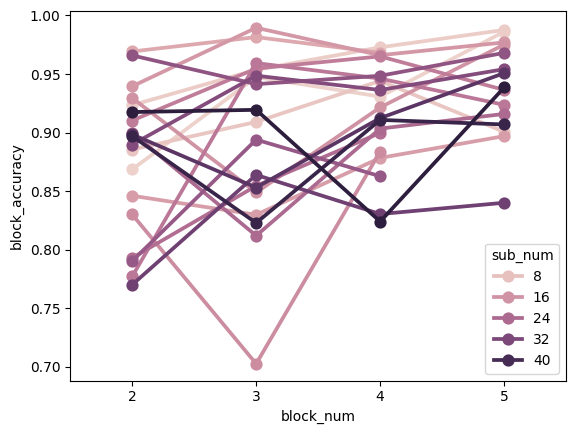

In [232]:
improvers = no_high_performers[no_high_performers.sub_num.isin([5, 6, 7, 12, 14, 15, 16, 17, 20, 21, 23, 24, 28, 29, 31, 34, 37, 42, 44])]
sns.pointplot(data = improvers, x = "block_num", y = "block_accuracy", hue = 'sub_num')

In [233]:
# no_high_performers = scores_by_block[~scores_by_block.sub_num.isin(subs)]
# med = np.nanmedian(no_high_performers['diff'])
# no_high_performers['improvement'] = np.where(no_high_performers['diff'] > med, 'high', 'low')
# improvers = no_high_performers[no_high_performers.improvement == 'high']
# sns.pointplot(data = improvers, x = "block_num", y = "block_accuracy", hue = 'sub_num', legend = False)
# plt.ylim(0.66, 1.02) 
# plt.savefig('../figs/improver.png', dpi = 300)
# print(np.unique(improvers.sub_num))

## Group 3: Decliners

In [234]:
# decliners = no_high_performers[~no_high_performers.sub_num.isin(subs)]
# print(np.unique(decliners.sub_num))
# sns.pointplot(data = decliners, x = "block_num", y = "block_accuracy", hue = 'sub_num')
# plt.ylim(0.66, 1.02) 


<Axes: xlabel='block_num', ylabel='block_accuracy'>

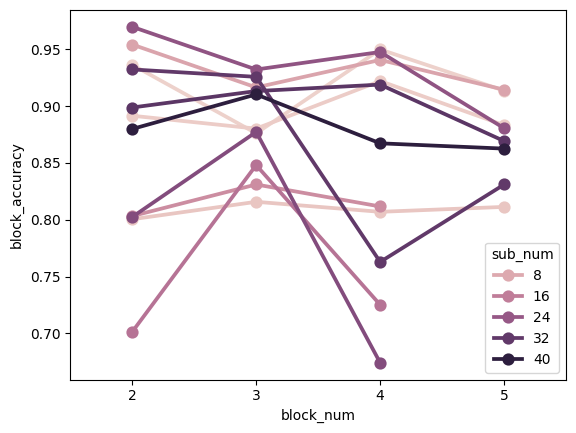

In [235]:
decliners = scores_by_block[scores_by_block.sub_num.isin([1, 2, 3, 9, 13, 18, 25, 27, 32, 33, 40])]
sns.pointplot(data = decliners, x = "block_num", y = "block_accuracy", hue = 'sub_num')

In [236]:
# decliners = no_high_performers[no_high_performers.improvement == 'low']
# sns.pointplot(data = decliners, x = "block_num", y = "block_accuracy", hue = 'sub_num', legend = False)
# plt.ylim(0.66, 1.02) 
# plt.savefig('../figs/decliner.png', dpi = 300)
# print(np.unique(decliners.sub_num))

In [237]:
# unclear = no_high_performers[no_high_performers.sub_num.isin([7, 12, 17, 23, 24, 28, 29, 40, 42])]
# unclear['sub_num'] = unclear['sub_num'].astype(str)
# sns.pointplot(data = unclear, x = "block_num", y = "block_accuracy", hue = 'sub_num')

#### Save dataframe

In [238]:
consistent_high_performers['group'] = 'high_performer'
improvers['group'] = 'improver'
decliners['group'] = 'decliner'
grouped = pd.concat([consistent_high_performers, improvers, decliners])
grouped = grouped[['sub_num', 'group']]
grouped = grouped.drop_duplicates()
grouped.to_csv('task-performance-groups.csv', index = False)

/home/letitiayhho/ipykernel_4034145/2888287042.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  consistent_high_performers['group'] = 'high_performer'
/home/letitiayhho/ipykernel_4034145/2888287042.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  improvers['group'] = 'improver'
/home/letitiayhho/ipykernel_4034145/2888287042.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do